In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import os
print(os.listdir())

['.ipynb_checkpoints', 'data-export (1).csv', 'traffic.ipynb']


In [3]:
df = pd.read_csv("data-export (1).csv")
df.head()

,# ----------------------------------------,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,Session primary channel group (Default channel...,Date + hour (YYYYMMDDHH),Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
1,Direct,2024041623,237,300,144,47.526666666666700,0.6075949367088610,4.673333333333330,0.48,1402
2,Organic Social,2024041719,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147
3,Direct,2024041723,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069
4,Organic Social,2024041718,187,256,125,32.16015625,0.6684491978609630,4.078125,0.48828125,1044


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3183 entries, 0 to 3182
Data columns (total 10 columns):
 #   Column                                      Non-Null Count  Dtype
---  ------                                      --------------  -----
 0   # ----------------------------------------  3183 non-null   str  
 1   Unnamed: 1                                  3183 non-null   str  
 2   Unnamed: 2                                  3183 non-null   str  
 3   Unnamed: 3                                  3183 non-null   str  
 4   Unnamed: 4                                  3183 non-null   str  
 5   Unnamed: 5                                  3183 non-null   str  
 6   Unnamed: 6                                  3183 non-null   str  
 7   Unnamed: 7                                  3183 non-null   str  
 8   Unnamed: 8                                  3183 non-null   str  
 9   Unnamed: 9                                  3183 non-null   str  
dtypes: str(10)
memory usage: 248.8 KB


In [6]:
df.isnull().sum()

# ----------------------------------------    0
Unnamed: 1                                    0
Unnamed: 2                                    0
Unnamed: 3                                    0
Unnamed: 4                                    0
Unnamed: 5                                    0
Unnamed: 6                                    0
Unnamed: 7                                    0
Unnamed: 8                                    0
Unnamed: 9                                    0
dtype: int64

In [7]:
print(df.columns)

Index(['# ----------------------------------------', 'Unnamed: 1',
       'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6',
       'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9'],
      dtype='str')


In [8]:
import pandas as pd
df=pd.read_csv("data-export (1).csv",skiprows=1)
print(df.head())

  Session primary channel group (Default channel group)  \
0                                             Direct      
1                                     Organic Social      
2                                             Direct      
3                                     Organic Social      
4                                     Organic Social      

   Date + hour (YYYYMMDDHH)  Users  Sessions  Engaged sessions  \
0                2024041623    237       300               144   
1                2024041719    208       267               132   
2                2024041723    188       233               115   
3                2024041718    187       256               125   
4                2024041720    175       221               112   

   Average engagement time per session  Engaged sessions per user  \
0                            47.526667                   0.607595   
1                            32.097378                   0.634615   
2                            39.939914   

In [9]:
df.columns = [
    "Traffic_Source",
    "DateHour",
    "Users",
    "Sessions",
    "Engaged_Sessions",
    "Avg_Engagement_Time",
    "Engaged_Sessions_Per_User",
    "Events_Per_Session",
    "Engagement_Rate",
    "Event_Count"
]

print(df.columns)

Index(['Traffic_Source', 'DateHour', 'Users', 'Sessions', 'Engaged_Sessions',
       'Avg_Engagement_Time', 'Engaged_Sessions_Per_User',
       'Events_Per_Session', 'Engagement_Rate', 'Event_Count'],
      dtype='str')


In [10]:
print("Total Users:", df["Users"].sum())
print("Total Sessions:", df["Sessions"].sum())

Total Users: 133440
Total Sessions: 162895


In [11]:
traffic = df.groupby("Traffic_Source")["Sessions"].sum()

print(traffic)

Traffic_Source
Direct            37203
Email                 3
Organic Search    33372
Organic Social    60627
Organic Video       141
Referral          30990
Unassigned          559
Name: Sessions, dtype: int64


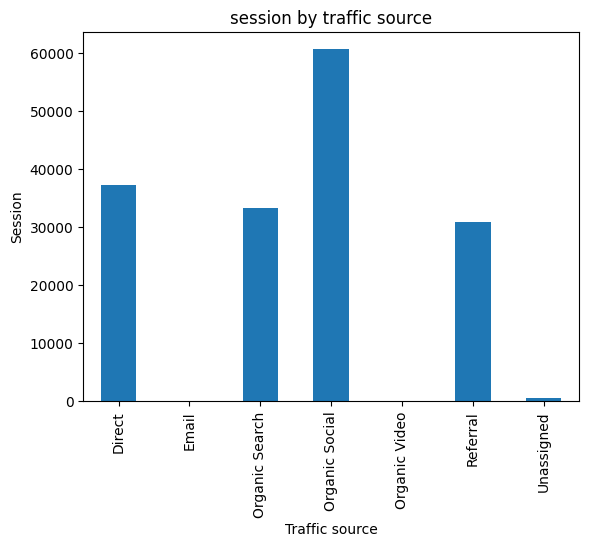

In [12]:
import matplotlib.pyplot as plt

traffic.plot(kind="bar")

plt.title("session by traffic source")
plt.xlabel("Traffic source")
plt.ylabel("Session")

plt.show()

In [14]:
print("Average Engagement Rate:",
      df["Engagement_Rate"].mean())

print("Average Engagement Time:",
      df["Avg_Engagement_Time"].mean())

Average Engagement Rate: 0.5033962593448201
Average Engagement Time: 66.6445811768324


In [15]:
top_source = traffic.idxmax()

print("Top Traffic Source:", top_source)

Top Traffic Source: Organic Social


In [16]:
print("Average Engagement Rate:",
      df["Engagement_Rate"].mean())

print("Average Engagement Time:",
      df["Avg_Engagement_Time"].mean())

print("Total Events:",
      df["Event_Count"].sum())

Average Engagement Rate: 0.5033962593448201
Average Engagement Time: 66.6445811768324
Total Events: 770911


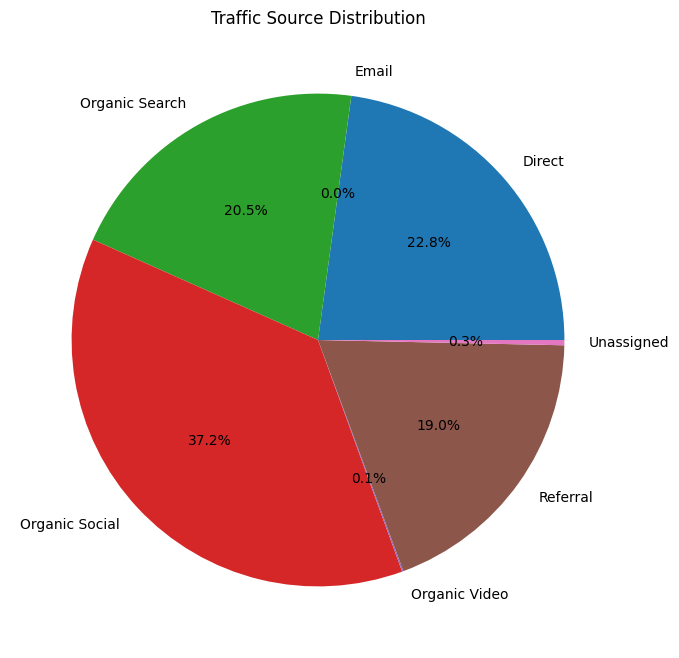

In [17]:
traffic.plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(8,8)
)

plt.title("Traffic Source Distribution")
plt.ylabel("")
plt.show()

Traffic_Source
Direct            30042
Email                 2
Organic Search    28387
Organic Social    47572
Organic Video       123
Referral          26774
Unassigned          540
Name: Users, dtype: int64


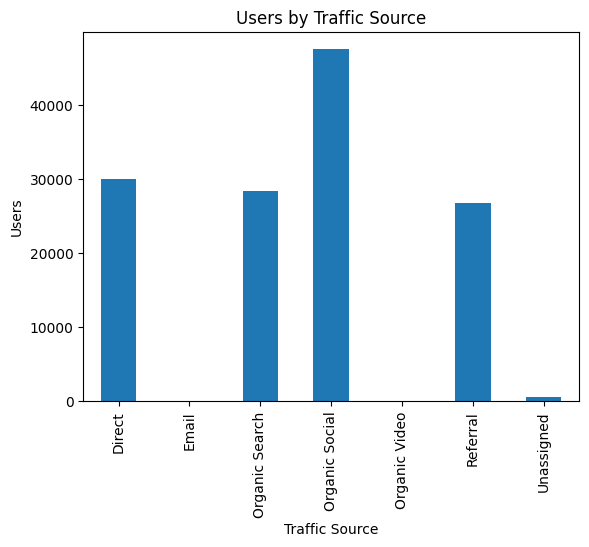

In [18]:
users = df.groupby("Traffic_Source")["Users"].sum()

print(users)

users.plot(kind="bar")
plt.title("Users by Traffic Source")
plt.xlabel("Traffic Source")
plt.ylabel("Users")
plt.show()